# Домашнее задание HW08-09

## Импорты и общие настройки

In [29]:
import os
import math
import time
import random
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
import csv
import json

import numpy as np

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

# Датасеты / трансформации
import torchvision
from torchvision import transforms

import matplotlib.pyplot as plt

import pandas as pd

# -----------------------
# Воспроизводимость
# -----------------------
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# -----------------------
# Устройство
# -----------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [4]:
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.10.0+cpu
torchvision: 0.25.0+cpu


## Вспомогательные функции

In [6]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    # Accuracy для классификации: logits -> argmax -> сравнение с y_true.
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def plot_history(history: dict, title: str = "") -> None:
    # history ожидается вида:
    # {
    #   "train_loss": [...], "val_loss": [...],
    #   "train_acc": [...],  "val_acc": [...]
    # }
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

In [16]:
RUNS_PATH = 'artifacts/runs.csv'

def log_run(
    experiment_id,
    dataset,
    seed,
    model,
    optimizer,
    lr,
    momentum,
    weight_decay,
    history
):

    best_val_acc = max(history["val_acc"])
    best_val_loss = min(history["val_loss"])
    epochs_trained = len(history["train_loss"])

    model_summary = (
        f"hidden={model.hidden_dims}, "
        f"dropout={model.dropout_p}, "
        f"batchnorm={model.use_batchnorm}"
    )

    row = {
        "experiment_id": experiment_id,
        "dataset": dataset,
        "seed": seed,
        "model_summary": model_summary,
        "optimizer": optimizer.__class__.__name__,
        "lr": lr,
        "momentum": momentum,
        "weight_decay": weight_decay,
        "epochs_trained": epochs_trained,
        "best_val_accuracy": best_val_acc,
        "best_val_loss": best_val_loss
    }

    file_exists = os.path.exists(RUNS_PATH)

    with open(RUNS_PATH, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=row.keys())

        if not file_exists:
            writer.writeheader()

        writer.writerow(row)

## Данные: загрузка, train/val/test, DataLoader

In [8]:
# Трансформации: ToTensor и Normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),  # mean/std для 1 канала
])

# Скачиваем датасет
train_full = torchvision.datasets.EMNIST(
    root="./data", train=True, download=True, transform=transform, split="balanced"
)
test_ds = torchvision.datasets.EMNIST(
    root="./data", train=False, download=True, transform=transform, split="balanced"
)

class_names = train_full.classes
print("classes:", class_names)
print("train size:", len(train_full))
print("test size:", len(test_ds))

100%|██████████| 562M/562M [00:50<00:00, 11.2MB/s] 


classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']
train size: 112800
test size: 18800


In [9]:
# Размер батча подстроим под наличие GPU
BATCH_SIZE = 256 if device.type == "cuda" else 64

# На Windows в Jupyter иногда бывают проблемы с multiprocessing в DataLoader.
# Поэтому автоматически ставим num_workers=0 на Windows, иначе 2.
NUM_WORKERS = 0 if os.name == "nt" else 2

# train/val split
val_ratio = 0.2
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(RANDOM_STATE)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

# Быстрый sanity-check
x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)
# Диапазоны значений
print("x min:", x_batch.min().item())
print("x max:", x_batch.max().item())

x_batch: torch.Size([64, 1, 28, 28]) torch.float32
y_batch: torch.Size([64]) torch.int64
x min: -1.0
x max: 1.0


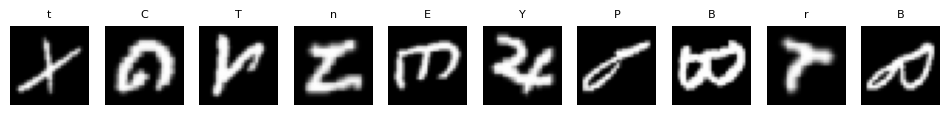

In [10]:
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n]
    y = y[:n]

    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        # Обратно денормализуем для отображения
        img = x[i].squeeze().numpy()
        img = img * 0.5 + 0.5
        plt.imshow(img, cmap="gray")
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_images(train_loader, n=10)

## Модель: MLP (nn.Module)

In [11]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (256, 128),
        num_classes: int = 47,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        self.hidden_dims = hidden_dims
        self.dropout_p = dropout_p
        self.use_batchnorm = use_batchnorm

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Быстрый sanity-check по форме
model = MLP(dropout_p=0.2, use_batchnorm=True).to(device)
with torch.no_grad():
    out = model(x_batch.to(device))
print("logits:", out.shape)

logits: torch.Size([64, 47])


## Цикл обучения: train/eval + no_grad

In [12]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()  # включаем train-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()  # включаем eval-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [13]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

## Эксперименты

### Часть A: регуляризация и переобучение

#### **E1 (base)**: MLP побольше (например, 2-3 скрытых слоя), без Dropout и без BatchNorm.

epoch 01/20 | train loss=1.1529, acc=0.6609 | val loss=0.7904, acc=0.7565
epoch 02/20 | train loss=0.6727, acc=0.7838 | val loss=0.6509, acc=0.7891
epoch 03/20 | train loss=0.5687, acc=0.8111 | val loss=0.5834, acc=0.8083
epoch 04/20 | train loss=0.5121, acc=0.8280 | val loss=0.5737, acc=0.8083
epoch 05/20 | train loss=0.4741, acc=0.8373 | val loss=0.5407, acc=0.8251
epoch 06/20 | train loss=0.4490, acc=0.8421 | val loss=0.5215, acc=0.8279
epoch 07/20 | train loss=0.4260, acc=0.8498 | val loss=0.5444, acc=0.8276
epoch 08/20 | train loss=0.4057, acc=0.8545 | val loss=0.5505, acc=0.8231
epoch 09/20 | train loss=0.3884, acc=0.8601 | val loss=0.5349, acc=0.8326
epoch 10/20 | train loss=0.3760, acc=0.8627 | val loss=0.5179, acc=0.8362
epoch 11/20 | train loss=0.3612, acc=0.8668 | val loss=0.5299, acc=0.8283
epoch 12/20 | train loss=0.3503, acc=0.8690 | val loss=0.5333, acc=0.8299
epoch 13/20 | train loss=0.3395, acc=0.8723 | val loss=0.5496, acc=0.8294
epoch 14/20 | train loss=0.3307, acc=0

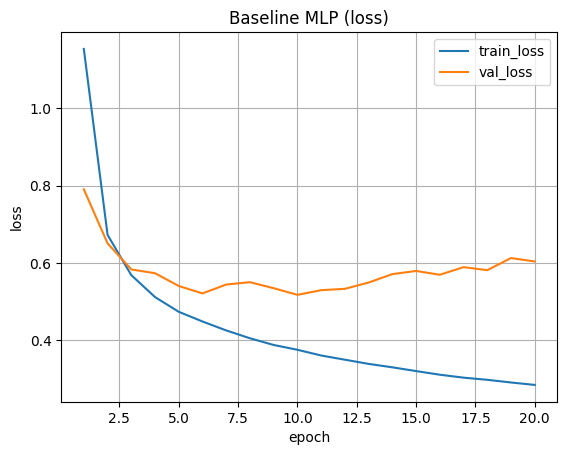

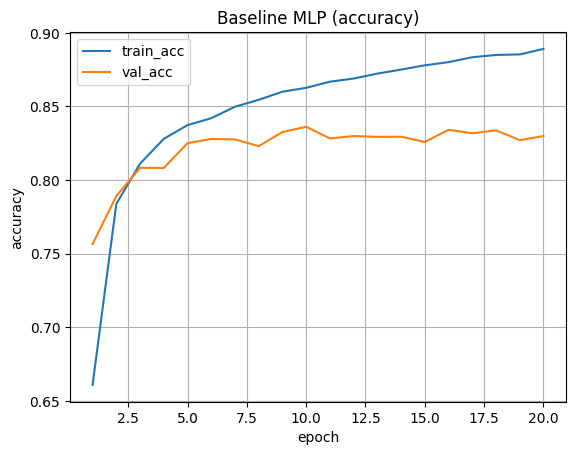

In [14]:
baseline = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

history_baseline = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_baseline, title="Baseline MLP")

In [17]:
log_run(
    experiment_id="E1",
    dataset="EMNIST",
    seed=RANDOM_STATE,
    model=baseline,
    optimizer=optimizer,
    lr=1e-3,
    momentum=0,
    weight_decay=0,
    history=history_baseline
)

#### **E2 (Dropout)**: как E1, но добавить Dropout (например, p=0.2-0.5).

epoch 01/20 | train loss=1.5587, acc=0.5433 | val loss=0.8660, acc=0.7304
epoch 02/20 | train loss=1.0454, acc=0.6783 | val loss=0.7258, acc=0.7685
epoch 03/20 | train loss=0.9458, acc=0.7026 | val loss=0.6660, acc=0.7892
epoch 04/20 | train loss=0.8956, acc=0.7168 | val loss=0.6486, acc=0.7913
epoch 05/20 | train loss=0.8608, acc=0.7276 | val loss=0.6186, acc=0.7944
epoch 06/20 | train loss=0.8343, acc=0.7334 | val loss=0.5933, acc=0.8058
epoch 07/20 | train loss=0.8116, acc=0.7392 | val loss=0.5972, acc=0.8060
epoch 08/20 | train loss=0.8052, acc=0.7403 | val loss=0.5723, acc=0.8100
epoch 09/20 | train loss=0.7927, acc=0.7448 | val loss=0.5740, acc=0.8129
epoch 10/20 | train loss=0.7851, acc=0.7466 | val loss=0.5637, acc=0.8156
epoch 11/20 | train loss=0.7747, acc=0.7486 | val loss=0.5627, acc=0.8108
epoch 12/20 | train loss=0.7676, acc=0.7498 | val loss=0.5654, acc=0.8150
epoch 13/20 | train loss=0.7620, acc=0.7520 | val loss=0.5592, acc=0.8138
epoch 14/20 | train loss=0.7551, acc=0

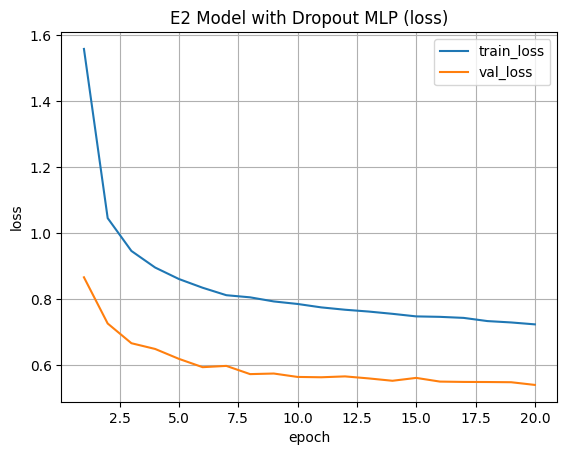

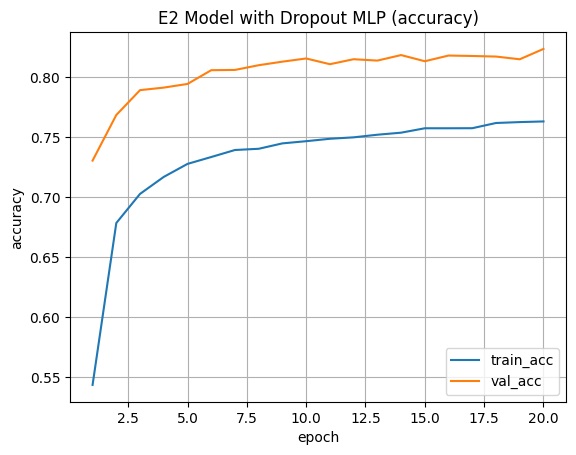

In [18]:
model_E2 = MLP(hidden_dims=(256, 128), dropout_p=0.3, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_E2.parameters(), lr=1e-3)

history_model_E2 = fit(
    model_E2, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_model_E2, title="E2 Model with Dropout MLP")

In [19]:
log_run(
    experiment_id="E2",
    dataset="EMNIST",
    seed=RANDOM_STATE,
    model=model_E2,
    optimizer=optimizer,
    lr=1e-3,
    momentum=0,
    weight_decay=0,
    history=history_model_E2
)

#### **E3 (BatchNorm)**: как E1, но добавить BatchNorm (между Linear и активацией).

epoch 01/20 | train loss=0.9223, acc=0.7354 | val loss=0.5984, acc=0.8019
epoch 02/20 | train loss=0.5405, acc=0.8199 | val loss=0.5205, acc=0.8255
epoch 03/20 | train loss=0.4673, acc=0.8394 | val loss=0.4972, acc=0.8281
epoch 04/20 | train loss=0.4228, acc=0.8511 | val loss=0.4656, acc=0.8419
epoch 05/20 | train loss=0.3933, acc=0.8604 | val loss=0.4507, acc=0.8491
epoch 06/20 | train loss=0.3671, acc=0.8669 | val loss=0.4584, acc=0.8465
epoch 07/20 | train loss=0.3468, acc=0.8731 | val loss=0.4539, acc=0.8464
epoch 08/20 | train loss=0.3291, acc=0.8774 | val loss=0.4550, acc=0.8495
epoch 09/20 | train loss=0.3120, acc=0.8821 | val loss=0.4685, acc=0.8436
epoch 10/20 | train loss=0.2993, acc=0.8876 | val loss=0.4597, acc=0.8490
epoch 11/20 | train loss=0.2864, acc=0.8904 | val loss=0.4573, acc=0.8514
epoch 12/20 | train loss=0.2752, acc=0.8949 | val loss=0.4565, acc=0.8525
epoch 13/20 | train loss=0.2669, acc=0.8974 | val loss=0.4713, acc=0.8497
epoch 14/20 | train loss=0.2585, acc=0

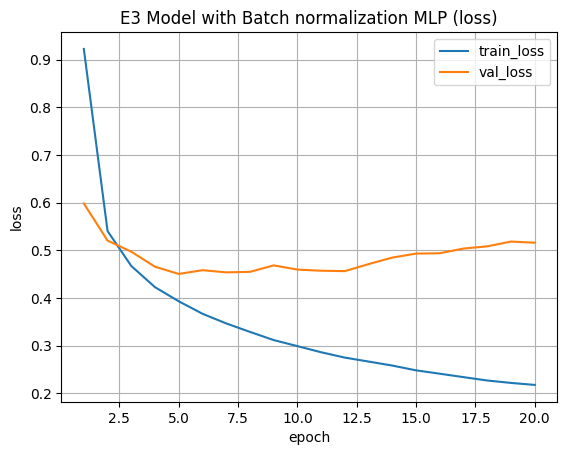

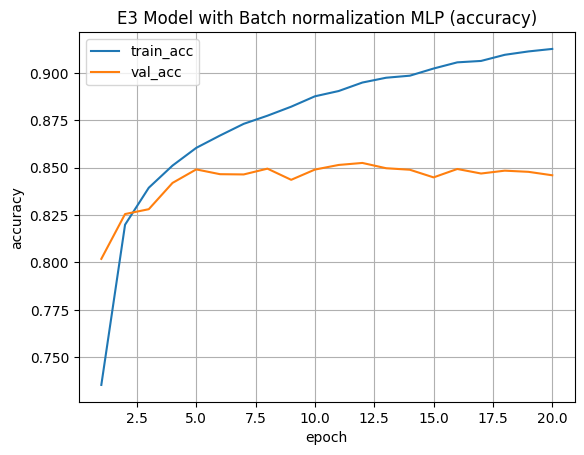

In [20]:
model_E3 = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_E3.parameters(), lr=1e-3)

history_model_E3 = fit(
    model_E3, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_model_E3, title="E3 Model with Batch normalization MLP")

In [21]:
log_run(
    experiment_id="E3",
    dataset="EMNIST",
    seed=RANDOM_STATE,
    model=model_E3,
    optimizer=optimizer,
    lr=1e-3,
    momentum=0,
    weight_decay=0,
    history=history_model_E3
)

#### **E4 (EarlyStopping)**: выбрать лучший из (E2/E3) по val_accuracy и обучить его с EarlyStopping (patience 3-5). Именно E4 считается "лучшей моделью домашки" и из него сохраняется best_model.pt.

Фиксируем архитектуру лучшей модели:

In [34]:
print(max(history_model_E2['val_acc']))
print(max(history_model_E3['val_acc']))

if max(history_model_E2['val_acc']) > max(history_model_E3['val_acc']):
  best_config = {
      "hidden_dims": (256,128),
      "dropout_p": 0.3,
      "use_batchnorm": False,
  }
else:
  best_config = {
      "hidden_dims": (256,128),
      "dropout_p": 0.0,
      "use_batchnorm": True,
  }

0.8235658640226629
0.8524699008498584


Лучшей моделью выбрана модель из эксперимента E3 (BatchNorm) с максимальной val_acc = 0.846778441011236.

In [23]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

epoch 01/20 | train loss=0.9246, acc=0.7349 | val loss=0.5791, acc=0.8121
epoch 02/20 | train loss=0.5410, acc=0.8205 | val loss=0.5057, acc=0.8316
epoch 03/20 | train loss=0.4662, acc=0.8395 | val loss=0.4752, acc=0.8375
epoch 04/20 | train loss=0.4219, acc=0.8516 | val loss=0.4591, acc=0.8487
epoch 05/20 | train loss=0.3920, acc=0.8604 | val loss=0.4637, acc=0.8435
epoch 06/20 | train loss=0.3668, acc=0.8672 | val loss=0.4685, acc=0.8397
epoch 07/20 | train loss=0.3468, acc=0.8728 | val loss=0.4577, acc=0.8470
epoch 08/20 | train loss=0.3296, acc=0.8778 | val loss=0.4600, acc=0.8480
EarlyStopping: остановка на эпохе 8. Лучший val_acc=0.8487


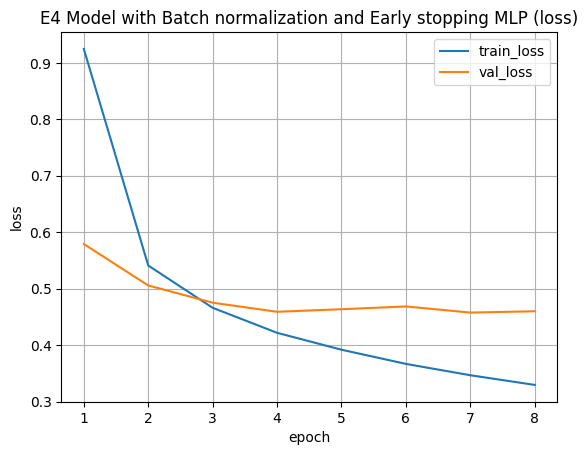

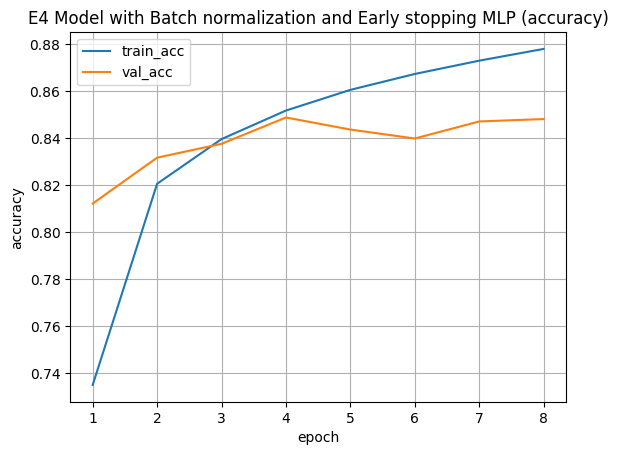

In [24]:
# best_config - зафиксированная архитектура лучшей модели
model_E4 = MLP(**best_config).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_E4.parameters(), lr=1e-3)

es = EarlyStopping(patience=4, min_delta=0.0005)

history_model_E4 = fit(
    model_E4, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=es
)

plot_history(history_model_E4, title="E4 Model with Batch normalization and Early stopping MLP")

Тестирование лучшей модели:

In [25]:
print('Test accuracy лучшей модели:', evaluate(model_E4, test_loader, nn.CrossEntropyLoss(), device)[1])

Test accuracy лучшей модели: 0.8391262755102041


Сохранение конфига и графиков обучения:

In [26]:
log_run(
    experiment_id="E4",
    dataset="EMNIST",
    seed=RANDOM_STATE,
    model=model_E4,
    optimizer=optimizer,
    lr=1e-3,
    momentum=0,
    weight_decay=0,
    history=history_model_E4
)

In [27]:
# Сохраняем state_dict лучшей модели
torch.save(model_E4.state_dict(), 'artifacts/best_model.pt')
print("Модель сохранена как best_model.pt")

Модель сохранена как best_model.pt


In [33]:
best_config_json = {
    "experiment_id": "E4",
    "dataset": "EMNIST",
    "seed": int(RANDOM_STATE),
    "model": {
        "hidden_dims": model.hidden_dims,
        "dropout_p": model.dropout_p,
        "use_batchnorm": model.use_batchnorm
    },
    "optimizer": optimizer.__class__.__name__,
    "lr": 1e-3,
    "momentum": 0,
    "weight_decay": 0
}

with open("artifacts/best_config.json", "w") as f:
    json.dump(best_config_json, f, indent=4)

print("best_config.json сохранён")

best_config.json сохранён


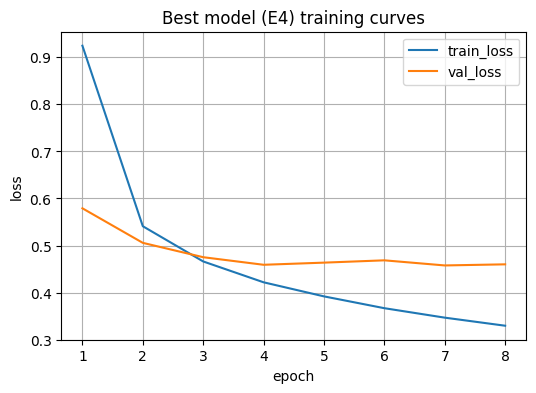

In [31]:
epochs = np.arange(1, len(history_model_E4["train_loss"]) + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs, history_model_E4["train_loss"], label="train_loss")
plt.plot(epochs, history_model_E4["val_loss"], label="val_loss")

plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Best model (E4) training curves")
plt.legend()
plt.grid(True)

plt.savefig("artifacts/figures/curves_best.png", dpi=300, bbox_inches="tight")
plt.show()

### Часть B (S09): LR, оптимизаторы, weight decay (обязательно)

#### **O1 (LR слишком большой)**: Adam, lr = "слишком большой" (например, 1e-1). Обучить 5-8 эпох и показать, что loss/метрики ведут себя плохо.

epoch 01/6 | train loss=1.2121, acc=0.6368 | val loss=0.9250, acc=0.7052
epoch 02/6 | train loss=0.8796, acc=0.7243 | val loss=0.7291, acc=0.7655
epoch 03/6 | train loss=0.8098, acc=0.7458 | val loss=0.7293, acc=0.7682
epoch 04/6 | train loss=0.7774, acc=0.7535 | val loss=0.6995, acc=0.7840
epoch 05/6 | train loss=0.7450, acc=0.7596 | val loss=0.7029, acc=0.7819
epoch 06/6 | train loss=0.7222, acc=0.7664 | val loss=0.6891, acc=0.7835


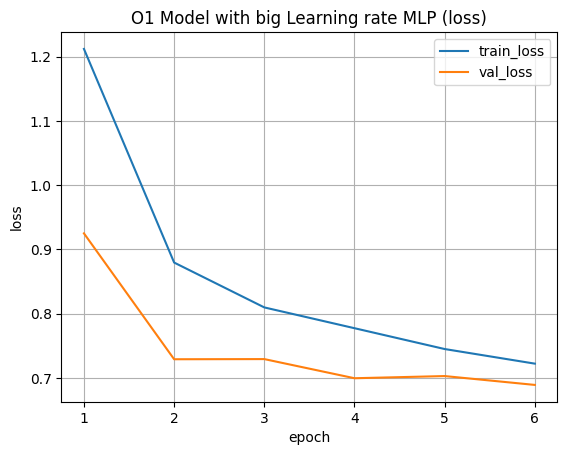

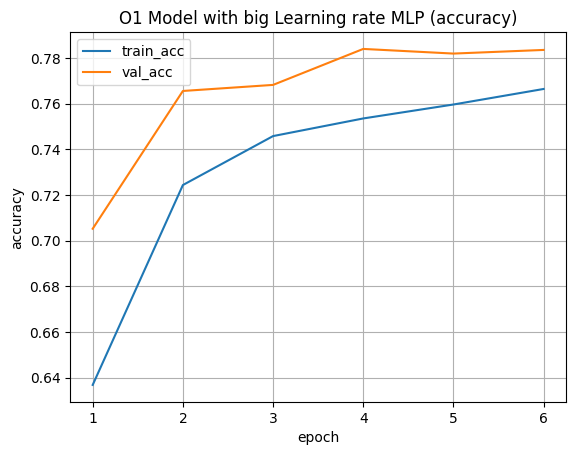

In [35]:
# best_config - зафиксированная архитектура лучшей модели
model_O1 = MLP(**best_config).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_O1.parameters(), lr=1e-1)

history_model_O1 = fit(
    model_O1, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=6,
    early_stopping=None
)

plot_history(history_model_O1, title="O1 Model with big Learning rate MLP")

In [36]:
log_run(
    experiment_id="O1",
    dataset="EMNIST",
    seed=RANDOM_STATE,
    model=model_O1,
    optimizer=optimizer,
    lr=1e-1,
    momentum=0,
    weight_decay=0,
    history=history_model_O1
)

#### **O2 (LR слишком маленький)**: Adam, lr = "слишком маленький" (например, 1e-5). Обучить 5-8 эпох и показать, что обучение почти не двигается.

epoch 01/6 | train loss=3.3192, acc=0.2431 | val loss=2.9160, acc=0.4312
epoch 02/6 | train loss=2.6939, acc=0.4938 | val loss=2.4692, acc=0.5511
epoch 03/6 | train loss=2.3205, acc=0.5723 | val loss=2.1423, acc=0.6056
epoch 04/6 | train loss=2.0327, acc=0.6158 | val loss=1.8893, acc=0.6395
epoch 05/6 | train loss=1.8036, acc=0.6433 | val loss=1.6701, acc=0.6640
epoch 06/6 | train loss=1.6150, acc=0.6661 | val loss=1.5113, acc=0.6814


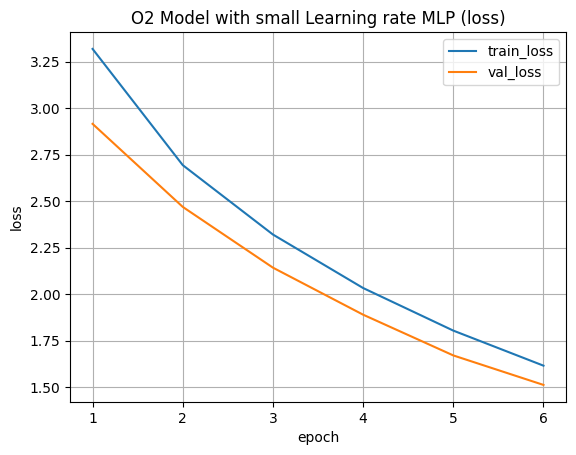

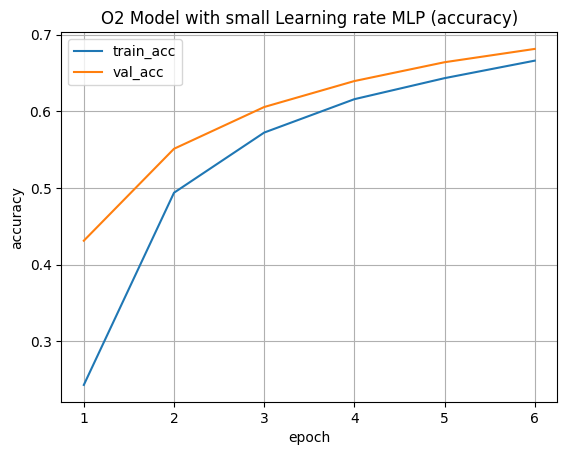

In [37]:
# best_config - зафиксированная архитектура лучшей модели
model_O2 = MLP(**best_config).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_O2.parameters(), lr=1e-5)

history_model_O2 = fit(
    model_O2, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=6,
    early_stopping=None
)

plot_history(history_model_O2, title="O2 Model with small Learning rate MLP")

In [38]:
log_run(
    experiment_id="O2",
    dataset="EMNIST",
    seed=RANDOM_STATE,
    model=model_O2,
    optimizer=optimizer,
    lr=1e-5,
    momentum=0,
    weight_decay=0,
    history=history_model_O2
)

#### **O3 (SGD+momentum + weight decay)**: SGD с momentum (например, momentum=0.9) и weight_decay > 0 (например, 1e-4).
*   lr взять разумный (например, как в E4 или подобрать в диапазоне 1e-2…1e-3).
*   обучить 10-15 эпох (или меньше, если на CPU долго).



epoch 01/12 | train loss=1.9525, acc=0.5676 | val loss=1.1521, acc=0.7073
epoch 02/12 | train loss=0.9767, acc=0.7379 | val loss=0.8045, acc=0.7735
epoch 03/12 | train loss=0.7409, acc=0.7846 | val loss=0.6757, acc=0.7971
epoch 04/12 | train loss=0.6311, acc=0.8099 | val loss=0.6000, acc=0.8149
epoch 05/12 | train loss=0.5636, acc=0.8243 | val loss=0.5687, acc=0.8221
epoch 06/12 | train loss=0.5187, acc=0.8355 | val loss=0.5354, acc=0.8271
epoch 07/12 | train loss=0.4844, acc=0.8433 | val loss=0.5182, acc=0.8349
epoch 08/12 | train loss=0.4580, acc=0.8498 | val loss=0.5049, acc=0.8377
epoch 09/12 | train loss=0.4386, acc=0.8557 | val loss=0.4951, acc=0.8388
epoch 10/12 | train loss=0.4181, acc=0.8605 | val loss=0.4931, acc=0.8395
epoch 11/12 | train loss=0.4032, acc=0.8641 | val loss=0.4804, acc=0.8406
epoch 12/12 | train loss=0.3886, acc=0.8690 | val loss=0.4808, acc=0.8428


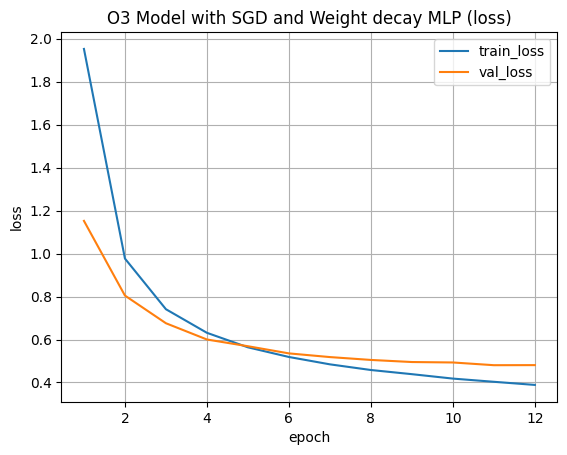

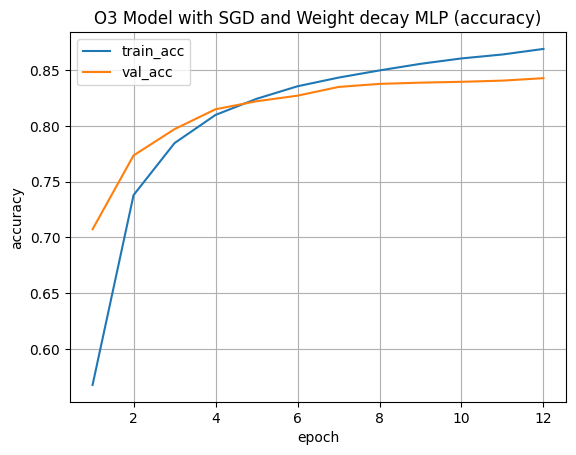

In [39]:
# best_config - зафиксированная архитектура лучшей модели
model_O3 = MLP(**best_config).to(device)

criterion = nn.CrossEntropyLoss()
# SGD с momentum и weight decay
optimizer = optim.SGD(
    model_O3.parameters(),
    lr=1e-3,
    momentum=0.9,
    weight_decay=1e-4
)

history_model_O3 = fit(
    model_O3, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=12,
    early_stopping=None
)

plot_history(history_model_O3, title="O3 Model with SGD and Weight decay MLP")

In [40]:
log_run(
    experiment_id="O3",
    dataset="EMNIST",
    seed=RANDOM_STATE,
    model=model_O3,
    optimizer=optimizer,
    lr=1e-3,
    momentum=0.9,
    weight_decay=1e-4,
    history=history_model_O3
)

Сохранение графиков обучения моделей из экспериментов O1 и O2:

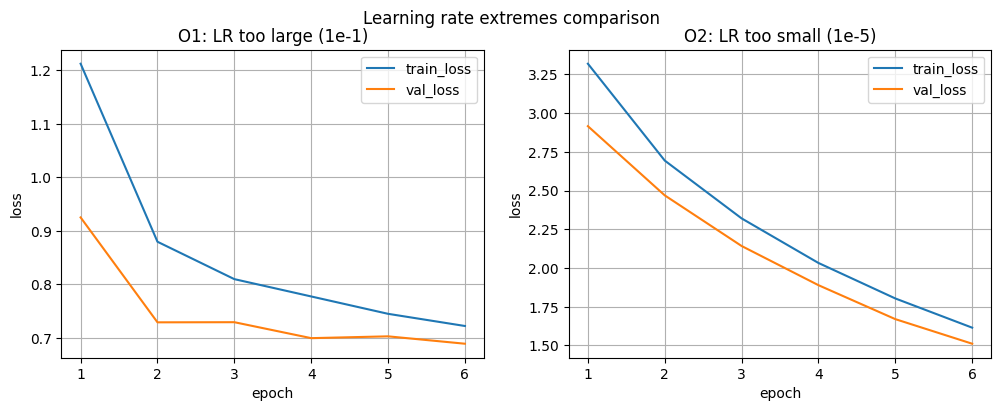

In [41]:
epochs_O1 = np.arange(1, len(history_model_O1["train_loss"]) + 1)
epochs_O2 = np.arange(1, len(history_model_O2["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12,4))

# O1 — слишком большой LR
axes[0].plot(epochs_O1, history_model_O1["train_loss"], label="train_loss")
axes[0].plot(epochs_O1, history_model_O1["val_loss"], label="val_loss")
axes[0].set_title("O1: LR too large (1e-1)")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].legend()
axes[0].grid(True)

# O2 — слишком маленький LR
axes[1].plot(epochs_O2, history_model_O2["train_loss"], label="train_loss")
axes[1].plot(epochs_O2, history_model_O2["val_loss"], label="val_loss")
axes[1].set_title("O2: LR too small (1e-5)")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Learning rate extremes comparison")

plt.savefig("artifacts/figures/curves_lr_extremes.png", dpi=300, bbox_inches="tight")
plt.show()